
 Fetch live currency exchange rates
● Compare multiple currencies
● Analyze currency fluctuations
● Create trend graphs
● Calculate conversion statistics
● Generate exchange reports

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import requests

API_KEY = "7675aecf29fe9dd81e0c6675"
# my_request=requests.get(f"https://v6.exchangerate-api.com/v6/{API_KEY}/latest/USD")
# print(my_request.status_code)
# data=my_request.json()
# print(data)


Live Currency Exchange Rates
  Currency      Rate
0      USD    1.0000
1      AED    3.6725
2      AFN   64.9260
3      ALL   82.2069
4      AMD  367.6455

Selected Currency Rates

   Currency      Rate
8       AUD    1.4394
26      CAD    1.4212
45      EUR    0.8746
49      GBP    0.7480
66      INR   95.4559
73      JPY  162.1289

Analysis

   Currency      Rate  Difference
8       AUD    1.4394    -42.2386
26      CAD    1.4212    -42.2568
45      EUR    0.8746    -42.8034
49      GBP    0.7480    -42.9300
66      INR   95.4559     51.7779
73      JPY  162.1289    118.4509

Converted Amounts

45.0 USD = 4295.52 INR
45.0 USD = 39.36 EUR
45.0 USD = 33.66 GBP
45.0 USD = 7295.80 JPY
45.0 USD = 64.77 AUD
45.0 USD = 63.95 CAD


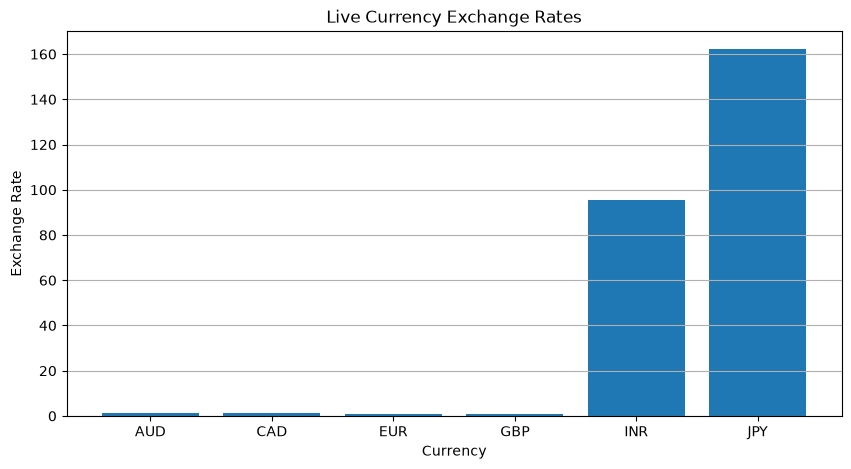


Report Saved Successfully
File Name : Currency_Exchange_Report.xlsx


In [ ]:
BASE_CURRENCY = "USD"

# API URL
url = f"https://v6.exchangerate-api.com/v6/{API_KEY}/latest/{BASE_CURRENCY}"

# -------------------------------
# Fetch Exchange Rates
# -------------------------------
response = requests.get(url)

if response.status_code == 200:
    data = response.json()

    if data["result"] == "success":
        rates = data["conversion_rates"]

        print("=" * 50)
        print("Live Currency Exchange Rates")
        print("=" * 50)

        # Convert dictionary to DataFrame
        df = pd.DataFrame(list(rates.items()), columns=["Currency", "Rate"])

        print(df.head())

        # -------------------------------
        # Compare Multiple Currencies
        # -------------------------------

        compare = ["INR", "EUR", "GBP", "JPY", "AUD", "CAD"]

        print("\nSelected Currency Rates\n")

        compare_df = df[df["Currency"].isin(compare)]

        print(compare_df)

        # -------------------------------
        # Analyze Currency Fluctuation
        # (Difference from Average Rate)
        # -------------------------------

        average_rate = compare_df["Rate"].mean()

        compare_df["Difference"] = compare_df["Rate"] - average_rate

        print("\nAnalysis\n")
        print(compare_df)

        # -------------------------------
        # Conversion Statistics
        # -------------------------------

        amount = float(input("\nEnter Amount in USD : "))

        print("\nConverted Amounts\n")

        for currency in compare:
            converted = amount * rates[currency]
            print(f"{amount} USD = {converted:.2f} {currency}")

        # -------------------------------
        # Trend Graph
        # -------------------------------

        plt.figure(figsize=(10, 5))

        plt.bar(compare_df["Currency"], compare_df["Rate"])

        plt.title("Live Currency Exchange Rates")
        plt.xlabel("Currency")
        plt.ylabel("Exchange Rate")
        plt.grid(axis="y")

        plt.show()

        # -------------------------------
        # Exchange Report
        # -------------------------------

        report = compare_df.copy()

        report["Base Currency"] = BASE_CURRENCY
        report["Average Rate"] = average_rate

        report.to_csv("Currency_Exchange_Report.csv", index=False)

        print("\nReport Saved Successfully")
        print("File Name : Currency_Exchange_Report.csv")

    else:
        print("API Error :", data["error-type"])

else:
    print("Request Failed")

In [ ]:
# df=pd.DataFrame(data)
# print(df.to_string())
# print(df.columns)

      result                          documentation                            terms_of_use  time_last_update_unix             time_last_update_utc  time_next_update_unix             time_next_update_utc base_code  conversion_rates
USD  success  https://www.exchangerate-api.com/docs  https://www.exchangerate-api.com/terms             1783296001  Mon, 06 Jul 2026 00:00:01 +0000             1783382401  Tue, 07 Jul 2026 00:00:01 +0000       USD      1.000000e+00
AED  success  https://www.exchangerate-api.com/docs  https://www.exchangerate-api.com/terms             1783296001  Mon, 06 Jul 2026 00:00:01 +0000             1783382401  Tue, 07 Jul 2026 00:00:01 +0000       USD      3.672500e+00
AFN  success  https://www.exchangerate-api.com/docs  https://www.exchangerate-api.com/terms             1783296001  Mon, 06 Jul 2026 00:00:01 +0000             1783382401  Tue, 07 Jul 2026 00:00:01 +0000       USD      6.477730e+01
ALL  success  https://www.exchangerate-api.com/docs  https://www.exchang

In [ ]:
# print(df['conversion_rates'])

USD      1.0000
AED      3.6725
AFN     64.7773
ALL     82.0842
AMD    368.2692
         ...   
YER    237.4211
ZAR     16.2270
ZMW     18.4057
ZWG     26.8147
ZWL     26.8147
Name: conversion_rates, Length: 166, dtype: float64


In [ ]:
# plt.plot(df['result'],df['conversion_rates'])
# plt.show()

In [ ]:
# print("average conversion rates ",df['conversion_rates'].mean())
# print("maximum conversion rates ",df['conversion_rates'].max())
# print("minimum conversion rates ",df['conversion_rates'].min())

average conversion rates  8522.105604578315
maximum conversion rates  1153550.6506
minimum conversion rates  0.02336
